# Transfer Learning v2 – Tối ưu cho Vietnam Data

### 🔧 Changelog v2.2 (Cross-Features & Outlier FIX):
1. ✅ **[NEW] Cross-features**: Thêm `sys_hydro_shift1`, `sys_coal_shift1` và rolling means vào hệ thống để TFT có thể học được **Mối quan hệ bù trừ** giữa điện Thủy điện và Điện than (Hạn hán → Than tăng).
2. ✅ **[FIX] Evaluation bug**: `actuals` từ `y[0]` dataloader (log-space), không phải `x['decoder_target']` (normalized)
3. ✅ **[FIX] Stage 3 dừng sớm**: Tách hẳn Stage 3 → không reload checkpoint, unfreeze in-place, tăng patience
4. ✅ **[FIX] Optimizer reset**: Dùng state_dict tự động xử lý tốt hơn

> **Yêu cầu**: `checkpoint/tft_v2_best.ckpt` từ `trainTFT_v2.ipynb`

In [56]:
# ── Cell 1: Import ────────────────────────────────────────────────────────────
import os, json, shutil, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import r2_score

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

pl.seed_everything(42, workers=True)
torch.set_float32_matmul_precision('high')

config_path = Path('checkpoint/model_config_v2.json')
if config_path.exists():
    with open(config_path, 'r') as f:
        model_cfg = json.load(f)
    LOG_TRANSFORM = model_cfg.get('LOG_TRANSFORM', True)
    print(f'✅ Config loaded – LOG_TRANSFORM={LOG_TRANSFORM}')
else:
    LOG_TRANSFORM = True
    print('⚠️ model_config_v2.json not found, LOG_TRANSFORM=True')

CHECKPOINT_PATH = 'checkpoint/tft_v2_best.ckpt'
print(f'Pretrained: {CHECKPOINT_PATH} | Exists: {os.path.exists(CHECKPOINT_PATH)}')

Seed set to 42


✅ Config loaded – LOG_TRANSFORM=True
Pretrained: checkpoint/tft_v2_best.ckpt | Exists: True


In [57]:
# ── Cell 2: Load & xử lý dữ liệu Vietnam ─────────────────────────────────────
path_vn = Path('data/processed/VN_data/full_vietnam_monthly.csv')
df_main = pd.read_csv(path_vn, sep=',')
print('Columns:', list(df_main.columns))

if 'series' in df_main.columns:
    df_main['series'] = df_main['series'].astype(str).str.strip()
    df_main = df_main[~df_main['series'].str.casefold().eq('total generation')].copy()

df_vn = df_main.rename(columns={
    'generation_twh': 'generation_TWh',
    'precip_mean': 'precipitation',
    'solar_mean': 'solar',
    'humidity_mean': 'humidity',
    'temp_mean': 'temperature'
})

raw_target = pd.to_numeric(df_vn['generation_TWh'], errors='coerce').fillna(0)
zero_ratio = (
    pd.DataFrame({'series': df_vn['series'], 'raw_target': raw_target})
    .groupby('series')['raw_target']
    .apply(lambda s: (s == 0).mean())
    .sort_values(ascending=False)
)
print('\nZero ratio per series:')
print(zero_ratio)

SPARSE_THRESHOLD = 0.60
sparse_series = zero_ratio[zero_ratio >= SPARSE_THRESHOLD].index.tolist()
if sparse_series:
    print(f'⚠️ Removing sparse series: {sparse_series}')
    df_vn = df_vn[~df_vn['series'].isin(sparse_series)].copy()

df_vn['generation_TWh'] = pd.to_numeric(df_vn['generation_TWh'], errors='coerce').fillna(0)
df_vn['generation_TWh'] = df_vn['generation_TWh'].replace(0, 1e-4).clip(lower=1e-4)

if LOG_TRANSFORM:
    df_vn['generation_TWh'] = np.log1p(df_vn['generation_TWh'])
    print('✅ log1p applied to target')

df_vn['date'] = pd.to_datetime(df_vn['date'])
df_vn = df_vn.sort_values(['entity', 'series', 'date']).reset_index(drop=True)

min_date = df_vn['date'].min()
df_vn['time_idx'] = (
    (df_vn['date'].dt.year - min_date.year) * 12
    + (df_vn['date'].dt.month - min_date.month)
).astype(int)
df_vn['month'] = df_vn['date'].dt.month.astype(str)
df_vn['month_sin'] = np.sin(2 * np.pi * df_vn['date'].dt.month / 12.0)
df_vn['month_cos'] = np.cos(2 * np.pi * df_vn['date'].dt.month / 12.0)

# === MỚI: TẠO CROSS-FEATURES THỦY ĐIỆN VÀ THAN ===
sys_hydro = df_vn[df_vn['series'] == 'Hydro'][['date', 'generation_TWh']].rename(columns={'generation_TWh': 'sys_hydro_gen'})
sys_coal = df_vn[df_vn['series'] == 'Coal'][['date', 'generation_TWh']].rename(columns={'generation_TWh': 'sys_coal_gen'})

sys_hydro = sys_hydro.groupby('date')['sys_hydro_gen'].mean().reset_index()
sys_coal = sys_coal.groupby('date')['sys_coal_gen'].mean().reset_index()

df_vn = df_vn.merge(sys_hydro, on='date', how='left')
df_vn = df_vn.merge(sys_coal, on='date', how='left')
df_vn['sys_hydro_gen'] = df_vn['sys_hydro_gen'].fillna(0)
df_vn['sys_coal_gen'] = df_vn['sys_coal_gen'].fillna(0)

def create_rolling_only(group):
    g = group.copy().sort_values('date')
    for w in [3, 6, 12]:
        g[f'target_roll_mean_{w}'] = g['generation_TWh'].shift(1).rolling(w, min_periods=1).mean()
        g[f'target_roll_std_{w}']  = g['generation_TWh'].shift(1).rolling(w, min_periods=1).std().fillna(0)

    # Cross-features (Shift 1 để không leak tương lai)
    if 'sys_hydro_gen' in g.columns:
        g['sys_hydro_shift1'] = g['sys_hydro_gen'].shift(1).fillna(0)
        g['sys_hydro_roll3_mean'] = g['sys_hydro_gen'].shift(1).rolling(3, min_periods=1).mean().fillna(0)
    if 'sys_coal_gen' in g.columns:
        g['sys_coal_shift1'] = g['sys_coal_gen'].shift(1).fillna(0)
        g['sys_coal_roll3_mean'] = g['sys_coal_gen'].shift(1).rolling(3, min_periods=1).mean().fillna(0)

    return g

df_vn = df_vn.groupby(['entity', 'series'], group_keys=False).apply(create_rolling_only)

roll_cols = [c for c in df_vn.columns if 'roll' in c or 'shift' in c]
for c in roll_cols:
    df_vn[c] = df_vn[c].replace(0, 1e-4).clip(lower=1e-4)
    df_vn[c] = df_vn.groupby(['entity', 'series'])[c].transform(lambda x: x.ffill())
    df_vn[c] = df_vn[c].fillna(1e-4)

exo_cols = [
    'precipitation', 'solar', 'humidity', 'temperature',
    'IPI_Value', 'CPI_Value', 'GDP_VND_Trillion', 'Oil_Price',
    'FDI_Disbursed_Monthly(bilionUSD)', 'FDI_Registered_Monthly(bilionUSD)'
]
for c in exo_cols:
    if c in df_vn.columns:
        df_vn[c] = df_vn.groupby(['entity', 'series'])[c].transform(lambda x: x.ffill().bfill())
        df_vn[c] = df_vn[c].fillna(0)
        q01, q99 = df_vn[c].quantile([0.01, 0.99])
        df_vn[c] = df_vn[c].clip(lower=q01, upper=q99)

for c in ['GDP_VND_Trillion', 'Oil_Price', 'FDI_Disbursed_Monthly(bilionUSD)', 'FDI_Registered_Monthly(bilionUSD)']:
    if c in df_vn.columns:
        df_vn[c] = np.log1p(pd.to_numeric(df_vn[c], errors='coerce').fillna(0).clip(lower=0))

print(f'\nRecords: {len(df_vn)}')
print(f'Series : {sorted(df_vn["series"].unique().tolist())}')
display(df_vn.head(2))

Columns: ['entity', 'entity code', 'date', 'series', 'is_aggregate_series', 'generation_TWh', 'IPI_Value', 'CPI_Value', 'GDP_VND_Trillion', 'Oil_Price', 'FDI_Disbursed_Monthly(bilionUSD)', 'FDI_Registered_Monthly(bilionUSD)', 'gas_price', 'castlecoal_price', 'castlecoal_vol', 'humidity', 'precipitation', 'solar', 'temperature']

Zero ratio per series:
series
Other fossil    0.736111
Wind            0.138889
Solar           0.041667
Coal            0.000000
Gas             0.000000
Hydro           0.000000
Name: raw_target, dtype: float64
⚠️ Removing sparse series: ['Other fossil']
✅ log1p applied to target

Records: 360
Series : ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']


,entity,entity code,date,series,is_aggregate_series,generation_TWh,IPI_Value,CPI_Value,GDP_VND_Trillion,Oil_Price,...,target_roll_mean_3,target_roll_std_3,target_roll_mean_6,target_roll_std_6,target_roll_mean_12,target_roll_std_12,sys_hydro_shift1,sys_hydro_roll3_mean,sys_coal_shift1,sys_coal_roll3_mean
0,Viet Nam,VNM,2019-01-01,Coal,False,2.363680,134.05,100.1,8.949105,4.098834,...,0.00010,0.0001,0.00010,0.0001,0.00010,0.0001,0.000100,0.000100,0.00010,0.00010
1,Viet Nam,VNM,2019-02-01,Coal,False,2.388763,108.37,100.8,8.949105,4.176385,...,2.36368,0.0001,2.36368,0.0001,2.36368,0.0001,1.479329,1.479329,2.36368,2.36368


In [58]:
# ── Cell 3: Tạo TimeSeriesDataSet ─────────────────────────────────────────────
max_encoder_length    = 36
max_prediction_length = 12
batch_size            = 32

min_len = max_encoder_length + max_prediction_length
series_len = df_vn.groupby(['entity', 'series'])['time_idx'].nunique().reset_index(name='n')
valid_groups = series_len.loc[series_len['n'] >= min_len, ['entity', 'series']]
df_vn_valid = df_vn.merge(valid_groups, on=['entity', 'series'], how='inner').copy()
df_vn_valid = df_vn_valid.reset_index(drop=True)

if df_vn_valid.empty:
    raise ValueError('No series long enough!')

training_cutoff = df_vn_valid['time_idx'].max() - max_prediction_length

known_candidates  = ['time_idx', 'month_sin', 'month_cos', 'precipitation', 'solar', 'humidity', 'temperature']
# ĐƯA CROSS-FEATURES VÀO ĐÂY ĐỂ LSTM HỌC ĐƯỢC CHÚNG NHƯ LÀ UNKNOWN BỞI VÌ TỪ T+2 TRỞ ĐI CHÚNG DỤA VÀO TƯƠNG LAI
unknown_candidates = [
    'generation_TWh',
    'target_roll_mean_3', 'target_roll_mean_6', 'target_roll_mean_12',
    'target_roll_std_3',  'target_roll_std_6',  'target_roll_std_12',
    'sys_hydro_shift1', 'sys_hydro_roll3_mean',
    'sys_coal_shift1', 'sys_coal_roll3_mean',
    'IPI_Value', 'CPI_Value', 'GDP_VND_Trillion',
    'Oil_Price',
    'FDI_Disbursed_Monthly(bilionUSD)', 'FDI_Registered_Monthly(bilionUSD)',
]

known_reals   = [c for c in known_candidates   if c in df_vn_valid.columns]
unknown_reals = [c for c in unknown_candidates if c in df_vn_valid.columns]
print('known_reals  :', known_reals)
print('unknown_reals:', unknown_reals)

training = TimeSeriesDataSet(
    df_vn_valid[lambda x: x.time_idx <= training_cutoff],
    time_idx='time_idx',
    target='generation_TWh',
    group_ids=['entity', 'series'],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=['entity', 'series'],
    time_varying_known_categoricals=['month'],
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=unknown_reals,
    target_normalizer=GroupNormalizer(
        groups=['entity', 'series'],
        center=True,
        transformation='softplus',
    ),
    lags={'generation_TWh': [1, 2, 3, 6, 12]},
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    df_vn_valid,
    min_prediction_idx=training_cutoff + 1,
    stop_randomization=True,
)

train_loader = training.to_dataloader(train=True,  batch_size=batch_size,     num_workers=0)
val_loader   = validation.to_dataloader(train=False, batch_size=batch_size * 2, num_workers=0)

print(f'\n✅ Dataset – train: {len(training)}, val: {len(validation)}')

known_reals  : ['time_idx', 'month_sin', 'month_cos', 'precipitation', 'solar', 'humidity', 'temperature']
unknown_reals: ['generation_TWh', 'target_roll_mean_3', 'target_roll_mean_6', 'target_roll_mean_12', 'target_roll_std_3', 'target_roll_std_6', 'target_roll_std_12', 'sys_hydro_shift1', 'sys_hydro_roll3_mean', 'sys_coal_shift1', 'sys_coal_roll3_mean', 'IPI_Value', 'CPI_Value', 'GDP_VND_Trillion', 'Oil_Price', 'FDI_Disbursed_Monthly(bilionUSD)', 'FDI_Registered_Monthly(bilionUSD)']

✅ Dataset – train: 185, val: 95


In [59]:
# ── Cell 4: Khởi tạo model & load pretrained ─────────────────────────────────
os.makedirs('checkpoint', exist_ok=True)
accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'

tft_vn = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-4,
    hidden_size=128,
    attention_head_size=4,
    dropout=0.15,
    hidden_continuous_size=64,
    loss=QuantileLoss(),
    log_interval=20,
    reduce_on_plateau_patience=5,
    optimizer='adamw',
    weight_decay=1e-3,
)
print(f'Model params: {tft_vn.size()/1e3:.1f}k')

# Load pretrained
n_t = n_m = p_t = p_m = 0
if os.path.exists(CHECKPOINT_PATH):
    pretrained_dict = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)['state_dict']
    model_dict = tft_vn.state_dict()
    matched_dict = {k: v for k, v in pretrained_dict.items()
                    if k in model_dict and v.shape == model_dict[k].shape}
    model_dict.update(matched_dict)
    tft_vn.load_state_dict(model_dict)
    n_t, n_m = len(model_dict), len(matched_dict)
    p_t = sum(v.numel() for v in model_dict.values())
    p_m = sum(v.numel() for v in matched_dict.values())
    print(f'🔁 Tensors: {n_m}/{n_t} ({n_m/max(n_t,1):.1%}) | Params: {p_m/1e3:.1f}k/{p_t/1e3:.1f}k ({p_m/max(p_t,1):.1%})')
else:
    print(f'⚠️ {CHECKPOINT_PATH} not found – training from scratch')

Model params: 1976.9k
🔁 Tensors: 566/756 (74.9%) | Params: 1655.9k/2015.5k (82.2%)


In [60]:
# ── Cell 5: Stage 1 – Warm-up (frozen backbone) ───────────────────────────────
print('== STAGE 1: Warm-up (frozen backbone) ==')
FREEZE_LAYERS = ['lstm_encoder', 'lstm_decoder', 'multihead_attn', 'post_attn_norm']
frozen = unfrozen = 0
for name, param in tft_vn.named_parameters():
    if any(f in name for f in FREEZE_LAYERS):
        param.requires_grad = False
        frozen += param.numel()
    else:
        param.requires_grad = True
        unfrozen += param.numel()
print(f'Frozen: {frozen/1e3:.1f}k | Trainable: {unfrozen/1e3:.1f}k')

tft_vn.hparams.learning_rate = 1e-4

cb_es_s1 = EarlyStopping(monitor='val_loss', min_delta=1e-5, patience=10, verbose=True, mode='min')
cb_ckpt_s1 = ModelCheckpoint(monitor='val_loss', mode='min',
                              filename='tft_vn_s1-{epoch:02d}-{val_loss:.4f}', save_top_k=1)
cb_lr_s1 = LearningRateMonitor()

trainer_s1 = pl.Trainer(
    max_epochs=30,
    accelerator=accelerator, devices=1,
    gradient_clip_val=0.5,
    callbacks=[cb_lr_s1, cb_es_s1, cb_ckpt_s1],
    enable_model_summary=False,
)
trainer_s1.fit(tft_vn, train_dataloaders=train_loader, val_dataloaders=val_loader)
print(f'Stage 1 best: {cb_ckpt_s1.best_model_score:.4f}')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


== STAGE 1: Warm-up (frozen backbone) ==
Frozen: 305.4k | Trainable: 1671.4k


Output()

Metric val_loss improved. New best score: 0.170


Metric val_loss improved by 0.018 >= min_delta = 1e-05. New best score: 0.152


...

Metric val_loss improved by 0.004 >= min_delta = 1e-05. New best score: 0.100


Metric val_loss improved by 0.004 >= min_delta = 1e-05. New best score: 0.096


Metric val_loss improved by 0.003 >= min_delta = 1e-05. New best score: 0.093


Monitored metric val_loss did not improve in the last 10 records. Best score: 0.093. Signaling Trainer to stop.


Stage 1 best: 0.0932


In [61]:
# ── Cell 6: Stage 2 – Partial unfreeze (LSTM thaw) ───────────────────────────
print('== STAGE 2: Partial unfreeze (LSTM thaw) ==')

if cb_ckpt_s1.best_model_path and os.path.exists(cb_ckpt_s1.best_model_path):
    ckpt = torch.load(cb_ckpt_s1.best_model_path, map_location='cpu', weights_only=False)
    tft_vn.load_state_dict(ckpt['state_dict'])
    print(f'Restored Stage 1 best weights')

STILL_FROZEN = ['multihead_attn', 'post_attn_norm']
frozen = unfrozen = 0
for name, param in tft_vn.named_parameters():
    if any(f in name for f in STILL_FROZEN):
        param.requires_grad = False
        frozen += param.numel()
    else:
        param.requires_grad = True
        unfrozen += param.numel()
print(f'Frozen: {frozen/1e3:.1f}k | Trainable: {unfrozen/1e3:.1f}k')

tft_vn.hparams.learning_rate = 5e-5

cb_es_s2 = EarlyStopping(monitor='val_loss', min_delta=1e-5, patience=15, verbose=True, mode='min')
cb_ckpt_s2 = ModelCheckpoint(monitor='val_loss', mode='min',
                              filename='tft_vn_s2-{epoch:02d}-{val_loss:.4f}', save_top_k=1)
cb_lr_s2 = LearningRateMonitor()

trainer_s2 = pl.Trainer(
    max_epochs=50,
    accelerator=accelerator, devices=1,
    gradient_clip_val=0.5,
    callbacks=[cb_lr_s2, cb_es_s2, cb_ckpt_s2],
    enable_model_summary=False,
)
trainer_s2.fit(tft_vn, train_dataloaders=train_loader, val_dataloaders=val_loader)
print(f'Stage 2 best: {cb_ckpt_s2.best_model_score:.4f}')

== STAGE 2: Partial unfreeze (LSTM thaw) ==
Restored Stage 1 best weights
Frozen: 41.2k | Trainable: 1935.6k


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

Metric val_loss improved. New best score: 0.095


Metric val_loss improved by 0.001 >= min_delta = 1e-05. New best score: 0.094


Monitored metric val_loss did not improve in the last 15 records. Best score: 0.094. Signaling Trainer to stop.


Stage 2 best: 0.0935


In [62]:
# ── Cell 7: Stage 3 – Full finetune ──────────────────────────────────────────
print('== STAGE 3: Full finetune (all layers) ==')

if cb_ckpt_s2.best_model_path and os.path.exists(cb_ckpt_s2.best_model_path):
    ckpt = torch.load(cb_ckpt_s2.best_model_path, map_location='cpu', weights_only=False)
    tft_vn.load_state_dict(ckpt['state_dict'])
    print(f'Restored Stage 2 best weights')

for param in tft_vn.parameters():
    param.requires_grad = True
total = sum(p.numel() for p in tft_vn.parameters())
print(f'All {total/1e3:.1f}k params unfrozen')

tft_vn.hparams.learning_rate = 2e-5

cb_es_s3 = EarlyStopping(monitor='val_loss', min_delta=5e-6, patience=20, verbose=True, mode='min')
best_ckpt_cb = ModelCheckpoint(
    dirpath='checkpoint',
    monitor='val_loss', mode='min',
    filename='tft_vn_best-{epoch:02d}-{val_loss:.4f}',
    save_top_k=1,
)
cb_lr_s3 = LearningRateMonitor()

trainer_s3 = pl.Trainer(
    max_epochs=120,
    accelerator=accelerator, devices=1,
    gradient_clip_val=0.5,
    callbacks=[cb_lr_s3, cb_es_s3, best_ckpt_cb],
    enable_model_summary=False,
)
trainer_s3.fit(tft_vn, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer_vn = trainer_s3
print(f'Stage 3 best: {best_ckpt_cb.best_model_score:.4f}')

== STAGE 3: Full finetune (all layers) ==


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Restored Stage 2 best weights
All 1976.9k params unfrozen


Output()

Metric val_loss improved. New best score: 0.095


Metric val_loss improved by 0.000 >= min_delta = 5e-06. New best score: 0.095


Monitored metric val_loss did not improve in the last 20 records. Best score: 0.095. Signaling Trainer to stop.


Stage 3 best: 0.0951


In [63]:
# ── Cell 8: Đánh giá (Fixed evaluation) ──────────────────────────────────────
if best_ckpt_cb.best_model_path and os.path.exists(best_ckpt_cb.best_model_path):
    print(f'Load: {best_ckpt_cb.best_model_path}')
    try:
        tft_vn = TemporalFusionTransformer.load_from_checkpoint(
            best_ckpt_cb.best_model_path, weights_only=False)
    except TypeError:
        tft_vn = TemporalFusionTransformer.load_from_checkpoint(best_ckpt_cb.best_model_path)

torch.set_grad_enabled(False)

raw_pred_obj = tft_vn.predict(val_loader, mode='raw', return_x=True)
if hasattr(raw_pred_obj, 'output'):
    raw_predictions = raw_pred_obj.output
    x_plot = getattr(raw_pred_obj, 'x', None)
elif isinstance(raw_pred_obj, tuple) and len(raw_pred_obj) == 2:
    raw_predictions, x_plot = raw_pred_obj
else:
    raw_predictions, x_plot = raw_pred_obj, None

point_pred_obj = tft_vn.predict(val_loader, mode='prediction')
point_predictions = point_pred_obj.output if hasattr(point_pred_obj, 'output') else point_pred_obj

actuals_list = []
for _, y in iter(val_loader):
    target = y[0] if isinstance(y, (list, tuple)) else y
    actuals_list.append(target.reshape(-1))
actuals_all = torch.cat(actuals_list, dim=0)

preds_all = point_predictions.detach().cpu().reshape(-1)
n = min(actuals_all.shape[0], preds_all.shape[0])
act_log = actuals_all[:n]
prd_log = preds_all[:n]

ok = torch.isfinite(act_log) & torch.isfinite(prd_log)
valid_count = int(ok.sum())
act_log, prd_log = act_log[ok], prd_log[ok]

print(f'act_log range: [{act_log.min():.3f}, {act_log.max():.3f}]')
print(f'prd_log range: [{prd_log.min():.3f}, {prd_log.max():.3f}]')

if LOG_TRANSFORM:
    act_twh = torch.expm1(act_log).clamp(min=0)
    prd_twh = torch.expm1(prd_log).clamp(min=0)
    mae_log  = (act_log - prd_log).abs().mean().item()
    rmse_log = torch.sqrt(((act_log - prd_log)**2).mean()).item()
    print(f'\n📊 Log-space: MAE={mae_log:.4f}, RMSE={rmse_log:.4f}')
else:
    act_twh, prd_twh = act_log, prd_log

mae  = (act_twh - prd_twh).abs().mean().item()
rmse = torch.sqrt(((act_twh - prd_twh)**2).mean()).item()
wape = ((act_twh - prd_twh).abs().sum() / (act_twh.abs().sum() + 1e-8)).item() * 100
r2   = r2_score(act_twh.numpy(), prd_twh.numpy())

print(f'\n--- OVERALL METRICS (TWh scale) ---')
print(f'MAE : {mae:.4f}  (target < 0.8)')
print(f'RMSE: {rmse:.4f}  (target ~ 1.1)')
print(f'WAPE: {wape:.4f}%  (target < 17%)')
print(f'R²  : {r2:.4f}')

Load: C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft_vn_best-epoch=03-val_loss=0.0951.ckpt


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightn

act_log range: [0.300, 2.895]
prd_log range: [0.423, 2.617]

📊 Log-space: MAE=0.1680, RMSE=0.2103

--- OVERALL METRICS (TWh scale) ---
MAE : 1.0865  (target < 0.8)
RMSE: 1.7032  (target ~ 1.1)
WAPE: 21.1479%  (target < 17%)
R²  : 0.8769


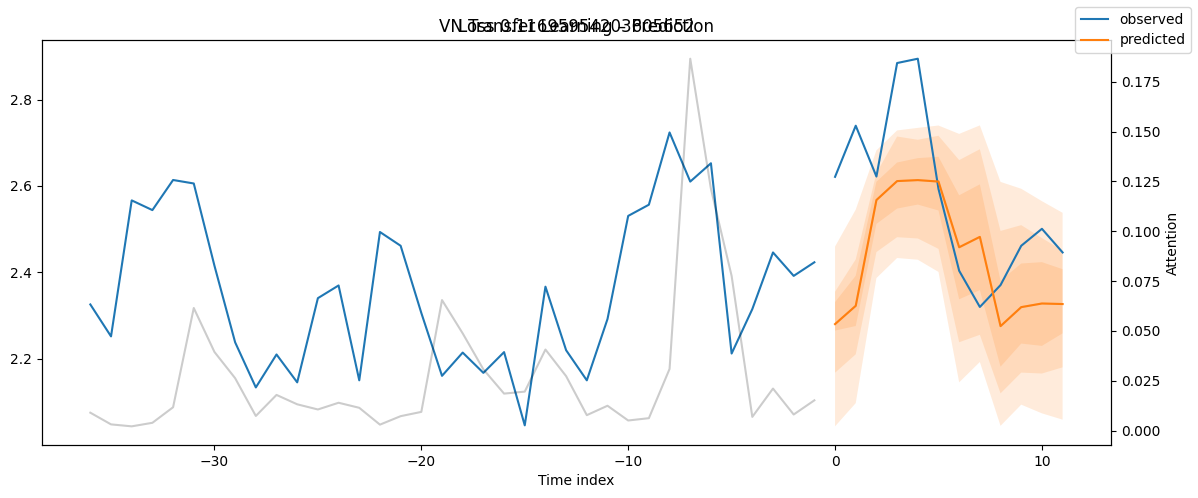

In [64]:
# ── Cell 9: Vẽ biểu đồ ─────────────────────────────────────────────────────
try:
    fig, ax = plt.subplots(figsize=(12, 5))
    _ = tft_vn.plot_prediction(x_plot, raw_predictions, idx=0, add_loss_to_title=True, ax=ax)
    plt.title('VN Transfer Learning – Prediction')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Plot error: {e}')

In [65]:
# ── Cell 10: Lưu model ───────────────────────────────────────────────────────
os.makedirs('checkpoint', exist_ok=True)
trainer_vn.save_checkpoint('checkpoint/tft_vn_model_latest.ckpt')
print('✅ Latest → checkpoint/tft_vn_model_latest.ckpt')

best_path = getattr(best_ckpt_cb, 'best_model_path', None)
if best_path and os.path.exists(best_path):
    shutil.copy(best_path, 'checkpoint/tft_vn_model_best.ckpt')
    print(f'✅ Best   → checkpoint/tft_vn_model_best.ckpt')
else:
    print('⚠️ No best checkpoint found')


`weights_only` was not set, defaulting to `False`.


✅ Latest → checkpoint/tft_vn_model_latest.ckpt
✅ Best   → checkpoint/tft_vn_model_best.ckpt
